# Twin4Build: Full Workflow Example

This notebook demonstrates the complete Twin4Build workflow on a single model:

1. **Semantic Model → Simulation Model** (Translator): Load a semantic description from an Excel file and automatically generate a simulation model
2. **Simulation Model → Calibrated Model** (Estimator): Calibrate the simulation model parameters against real sensor data
3. **Calibrated Model → Optimized Control** (Optimizer): Optimize the valve position schedule to minimize energy use while maintaining thermal comfort

The example uses a single-room office model with:
- A building space with thermal and mass balance
- A space heater with valve control
- Temperature and CO2 controllers with dampers
- Sensors for temperature, CO2, valve position, and damper position

Each of the three stages has its own dedicated notebook (`translator_example`, `estimator_example`, `optimizer_example`) with deeper explanations; this notebook shows how they chain together into an end-to-end digital-twin pipeline: *describe → calibrate → optimize*. The optimization stage goes one step further than `optimizer_example`: instead of minimizing energy, it minimizes **electricity cost** against real Danish spot prices, so the optimal strategy involves shifting heating to cheap hours.

> **Note:** this notebook reads sensor data from the external `Twin4build-Case-Studies` dataset. If that dataset is not available on your machine, run the three stage-specific notebooks instead, which use bundled example data.

## 1. Setup

Import the necessary packages. If running in Google Colab, uncomment the pip install line.
Note that Colab has a dependency issue and asks you to restart the runtime. It will work after you restart the runtime and run the cell a 2nd time.

In [1]:
# %pip install twin4build  # Uncomment in google colab
import datetime
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import torch
from dateutil import tz

import twin4build as tb
import twin4build.examples.utils as utils


---
# Part 1: Semantic Model → Simulation Model (Translator)

The Translator automatically generates a simulation model from a semantic description stored in an Excel file. The semantic file contains building component definitions using SAREF ontologies, component relationships, parameter specifications, and system topology.

We also define a custom configuration function (`fcn`) that adds connections and data sources not captured in the semantic model—such as supply water temperature, boundary conditions, sensor data files, and control setpoints.

### 1.1 Define Post-Translation Configuration

This function is called after the translator generates the simulation model. It adds:
- Supply water temperature and boundary temperature schedules
- Sensor data file connections (temperature, CO2, valve position, damper position, supply air temperature)
- Control setpoints (CO2, occupancy, temperature heating setpoint)
- Outdoor environment data (temperature, irradiation, CO2 concentration)

In [2]:
def fcn(self):
    """Post-translation configuration applied after the translator runs.

    Adds:
    - Supply water temperature (piecewise linear in outdoor temperature)
      and boundary temperature schedules
    - Sensor data file connections (temperature, CO2, valve position,
      damper position, supply air temperature)
    - CO2 setpoint and an inverse-CO2 occupancy estimator that replaces
      the constant-zero occupancy schedule
    - Occupancy-driven minimum-ventilation controller wired through a
      max selector with the CO2 PID controller
    - Heating setpoint and outdoor environment data
    """
    supply_water_schedule = tb.PiecewiseLinearScheduleSystem(
        defaultX=[-12, 5, 20],
        defaultY=[60, 50, 20],
        id="supply_water_schedule",
    )

    boundary_temp_schedule = tb.ScheduleSystem(
        weekDayRulesetDict={
            "ruleset_default_value": 21,
            "ruleset_start_minute": [],
            "ruleset_end_minute": [],
            "ruleset_start_hour": [],
            "ruleset_end_hour": [],
            "ruleset_value": [],
        },
        weekendRulesetDict={
            "ruleset_default_value": 21,
            "ruleset_start_minute": [],
            "ruleset_end_minute": [],
            "ruleset_start_hour": [],
            "ruleset_end_hour": [],
            "ruleset_value": [],
        },
        id="boundary_temp_schedule",
    )

    # The wall toward the neighbouring (unmodeled) space: the office couples
    # to the boundary-temperature schedule through a 2R1C WallTorchSystem.
    # The wall owns the wall state, so the heat exchange is energy-consistent
    # by construction (see the WallTorchSystem docstring).
    boundary_wall = tb.WallTorchSystem(C=1e6, R_a=0.02, R_b=0.02, id="office_boundary_wall")
    self.add_connection(self.components["office"], boundary_wall, "indoorTemperature", "temperatureA")
    self.add_connection(boundary_temp_schedule, boundary_wall, "scheduleValue", "temperatureB")
    self.add_connection(boundary_wall, self.components["office"], "heatFlowRateA", "wallHeatGain", input_port_index=0)
    self.add_connection(self.components["outdoor_environment"], supply_water_schedule, "outdoorTemperature", "x")
    self.add_connection(supply_water_schedule, self.components["office_space_heater"], "scheduleValue", "supplyWaterTemperature")

    DATA_ROOT = r"C:\Users\jabj\Documents\python\Twin4build-Case-Studies\DP37\model\data"

    # --- Room 11A sensors ---
    self.components["office_temperature_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_011A\OD095_01_011A_L95_LC02_BQA001_S1.plc_SENSOR_VALUE.csv"
    self.components["office_temperature_sensor"].datecolumn = 2
    self.components["office_temperature_sensor"].valuecolumn = 4

    self.components["office_co2_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_011A\OD095_01_011A_L95_LC02_BQA001_S2.plc_SENSOR_VALUE.csv"
    self.components["office_co2_sensor"].datecolumn = 2
    self.components["office_co2_sensor"].valuecolumn = 4

    self.components["office_valve_position_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_011A\OD095_01_011A_L95_LC02_QNA001_C1.plc_ACTUATOR_VALUE.csv"
    self.components["office_valve_position_sensor"].datecolumn = 2
    self.components["office_valve_position_sensor"].valuecolumn = 4

    self.components["office_damper_position_sensor"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_011A\OD095_01_011A_L95_LC02_QNB001_C1.plc_ACTUATOR_VALUE.csv"
    self.components["office_damper_position_sensor"].datecolumn = 2
    self.components["office_damper_position_sensor"].valuecolumn = 4

    # Supply air temperature (AHU-level, same for all rooms).
    # The translator's MILP only materialises this sensor when an upstream
    # physics component (AHU, coil, ...) is present to consume its
    # ``measuredValue`` -- in the bare single-room SAREF spreadsheet there
    # is no AHU, so the sensor is pruned and we silently skip the binding.
    if "supply_air_temperature_sensor" in self.components:
        self.components["supply_air_temperature_sensor"].filename = DATA_ROOT + r"\Time series\HF04\OD095_01_032A_J95_HF04_BTA004_S1.plc_SENSOR_VALUE.csv"
        self.components["supply_air_temperature_sensor"].datecolumn = 2
        self.components["supply_air_temperature_sensor"].valuecolumn = 4

    self.components["office_co2_setpoint"].weekDayRulesetDict = {
        "ruleset_default_value": 900,
        "ruleset_start_minute": [],
        "ruleset_end_minute": [],
        "ruleset_end_hour": [],
        "ruleset_start_hour": [],
        "ruleset_value": [],
    }

    # Replace constant-zero occupancy schedule with inverse-CO2 estimator.
    # Indoor CO2 and damper position are read directly from CSV (real measurements)
    # to avoid a gradient feedback loop through simulated sensor outputs.
    self.remove_component(self.components["office_occupancy_profile"])
    occupancy_system = tb.OccupancySystem(
        V=100,
        G_occ=5e-6,
        m_inf=0.001,
        co2_filename=DATA_ROOT + r"\Time series\Rooms\OD095_01_011A\OD095_01_011A_L95_LC02_BQA001_S2.plc_SENSOR_VALUE.csv",
        co2_datecolumn=2,
        co2_valuecolumn=4,
        damper_filename=DATA_ROOT + r"\Time series\Rooms\OD095_01_011A\OD095_01_011A_L95_LC02_QNB001_C1.plc_ACTUATOR_VALUE.csv",
        damper_datecolumn=2,
        damper_valuecolumn=4,
        id="office_occupancy",
    )
    self.add_connection(self.components["outdoor_environment"], occupancy_system, "outdoorCo2Concentration", "outdoorCo2Concentration")
    self.add_connection(occupancy_system, self.components["office"], "scheduleValue", "numberOfPeople")

    # --- Occupancy-driven minimum-ventilation controller ---
    # Remove existing CO2 controller -> damper connections (from semantic model)
    self.remove_connection(self.components["office_co2_controller"], self.components["office_supply_damper"], "inputSignal", "damperPosition")
    self.remove_connection(self.components["office_co2_controller"], self.components["office_exhaust_damper"], "inputSignal", "damperPosition")

    # Occupancy detector: continuous N_occ -> smooth binary (0/1)
    occupancy_detector = tb.OccupancyDetectorSystem(
        threshold=1,
        id="office_occupancy_detector",
    )
    self.add_connection(occupancy_system, occupancy_detector, "scheduleValue", "occupancy")

    # On/off controller: binary occupancy -> minimum damper position (0.3 when occupied)
    occupancy_controller = tb.OnOffControllerTorchSystem(
        onValue=0.3,
        offValue=0.0,
        isReverse=False,
        id="office_occupancy_controller",
    )
    self.add_connection(occupancy_detector, occupancy_controller, "occupancySignal", "actualValue")

    # Constant setpoint at 0.5 (midpoint of the 0-1 detector signal)
    occupancy_controller_setpoint = tb.ScheduleSystem(
        weekDayRulesetDict={
            "ruleset_default_value": 0.5,
            "ruleset_start_minute": [],
            "ruleset_end_minute": [],
            "ruleset_start_hour": [],
            "ruleset_end_hour": [],
            "ruleset_value": [],
        },
        id="office_occupancy_controller_setpoint",
    )
    self.add_connection(occupancy_controller_setpoint, occupancy_controller, "scheduleValue", "setpointValue")

    # Max selector: final damper position = max(CO2 PID output, occupancy on/off output)
    damper_max = tb.MaxSystem(id="office_damper_max")
    self.add_connection(self.components["office_co2_controller"], damper_max, "inputSignal", "inputs", input_port_index=0)
    self.add_connection(occupancy_controller, damper_max, "inputSignal", "inputs", input_port_index=1)
    self.add_connection(damper_max, self.components["office_supply_damper"], "value", "damperPosition")
    self.add_connection(damper_max, self.components["office_exhaust_damper"], "value", "damperPosition")

    # Rewire damper position sensor to read actual damper position (after MaxSystem)
    self.remove_connection(self.components["office_co2_controller"], self.components["office_damper_position_sensor"], "inputSignal", "measuredValue")
    self.add_connection(damper_max, self.components["office_damper_position_sensor"], "value", "measuredValue")

    # Heating setpoint for room 11A
    self.components["office_temperature_heating_setpoint"].filename = DATA_ROOT + r"\Time series\Rooms\OD095_01_011A\OD095_01_011A_L95_LC02_KFD001.plc_PID_SP.csv"
    self.components["office_temperature_heating_setpoint"].datecolumn = 2
    self.components["office_temperature_heating_setpoint"].valuecolumn = 4

    self.components["outdoor_environment"].useSpreadsheet = True
    self.components["outdoor_environment"].filename_outdoorTemperature = utils.get_path(["estimator_example", "outdoor_environment.csv"])
    self.components["outdoor_environment"].datecolumn_outdoorTemperature = 0
    self.components["outdoor_environment"].valuecolumn_outdoorTemperature = 1

    self.components["outdoor_environment"].filename_globalIrradiation = utils.get_path(["estimator_example", "outdoor_environment.csv"])
    self.components["outdoor_environment"].datecolumn_globalIrradiation = 0
    self.components["outdoor_environment"].valuecolumn_globalIrradiation = 2

    self.components["outdoor_environment"].filename_outdoorCo2Concentration = utils.get_path(["estimator_example", "outdoor_environment.csv"])
    self.components["outdoor_environment"].datecolumn_outdoorCo2Concentration = 0
    self.components["outdoor_environment"].valuecolumn_outdoorCo2Concentration = 3

    # UA will be estimated -- disable the automatic re-computation from nominal
    # values so initialize() preserves the calibrated/set value.  This is
    # serialized via the config so loading from RDF also gets False.
    self.components["office_space_heater"].initialize_UA = False


### 1.2 Load and Translate the Semantic Model

Create a model, load the semantic description from the Excel file, and apply the post-translation configuration. The `model.load()` call internally runs the Translator to produce an executable simulation model.

In [3]:
# Re-serialize: uncomment `model.serialize()` below if you want to persist
# the translated graph to `instance_graph.ttl` for the warm path.
model = tb.Model(id="full_workflow_example")
filename = utils.get_path(["estimator_example", "one_room_example_model.xlsm"])
model.load(semantic_model_filename=filename, fcn=fcn)
print("Serializing model...")
# model.serialize()

# Load from serialized model (comment out the block above after re-serializing)
# model = tb.Model(id="full_workflow_example")
# filename_simulation, _ = model._simulation_model._semantic_model.get_dir(
#     filename="instance_graph.ttl"
# )
# model.load(simulation_model_filename=filename_simulation)
print(model)


C:\Users\jabj\Documents\python\Twin4Build\twin4build\model\semantic_model\semantic_model.py:692: UserWarning: Failed to parse namespace for type na0faf8f3e31549b49ccb2c968348d90fb211. Reasoning involving this type will not be possible.
  warnings.warn(message)
C:\Users\jabj\Documents\python\Twin4Build\twin4build\model\semantic_model\semantic_model.py:692: UserWarning: Failed to parse namespace for type na0faf8f3e31549b49ccb2c968348d90fb212. Reasoning involving this type will not be possible.
  warnings.warn(message)
C:\Users\jabj\Documents\python\Twin4Build\twin4build\model\semantic_model\semantic_model.py:692: UserWarning: Failed to parse namespace for type na0faf8f3e31549b49ccb2c968348d90fb297. Reasoning involving this type will not be possible.
  warnings.warn(message)
C:\Users\jabj\Documents\python\Twin4Build\twin4build\model\semantic_model\semantic_model.py:692: UserWarning: Failed to parse namespace for type na0faf8f3e31549b49ccb2c968348d90fb298. Reasoning involving this type wil

Serializing model...
+-------------------------------------------------------------------------------------------------------------------------------+
|                                          Model overview    id: full_workflow_example                                          |
+---------------------------------------------+---------------------------------------------------------------------------------+
|  Number of components in simulation model:  |                                        22                                       |
+---------------------------------------------+---------------------------------------------------------------------------------+
| Number of connections in simulation model:  |                                        30                                       |
+---------------------------------------------+---------------------------------------------------------------------------------+
|              Model directory:               | C:\Users\jabj\AppData

### 1.3 Visualize the Models

Visualize both the semantic model graph and the simulation model graph to understand the component topology.

In [4]:
# instance_style = {
#     "http://example.org/building#cooling_coil_airside": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#cooling_coil_waterside": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#cooling_coil": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#cooling_system": {"fill_color": ["#8497B0", "#8497B0", None, None]},
#     "http://example.org/building#heating_system": {"fill_color": ["#873939", "#873939", None, None]},
#     "http://example.org/building#ventilation_system": {"fill_color": ["#44546A", "#44546A", None, None]},
# }

# query = """
#     CONSTRUCT { ?s ?p ?o }
#     WHERE {
#         ?s ?p ?o .
#         FILTER (?p != rdf:type && ?p != rdfs:subClassOf)
#         FILTER NOT EXISTS { ?s rdf:type s4syst:System }
#         FILTER NOT EXISTS { ?o rdf:type s4syst:System }
#     }
# """
# initial_node = "http://example.org/building#office"
# model.semantic_model.visualize(
#     format="svg", instance_style=instance_style, deduplicate_inverse=True,
#     include_full_uri=False, query=query, initial_node=initial_node,
#     node_limit=35, traversal_mode="bfs", dpi=800
# )
# model.simulation_model.visualize(
#     format="svg", instance_style=instance_style, deduplicate_inverse=True,
#     include_full_uri=False, literals=False, dpi=800, compressed=True
# )

---
# Part 2: Simulation Model → Calibrated Model (Estimator)

With the simulation model ready, we now calibrate its parameters against real sensor data. The Estimator solves a maximum-likelihood problem: find the parameter vector that minimizes the standard-deviation-weighted mean squared error between simulated and measured sensor outputs. We use single-shooting with the SLSQP optimizer, where gradients come from automatic differentiation through the simulation. See `estimator_example.ipynb` for a discussion of the available methods (including the fast composer-based objective and CasADi collocation).

### 2.1 Set Up Simulation Parameters

Define the estimation period and step size. `start_time`/`end_time` are lists — the Estimator supports multiple disjoint periods (useful for capturing different operating regimes), though here a single 5-day period suffices. The weekday printouts confirm the period spans working days, when the room is actually occupied and controlled.

In [5]:
simulator = tb.Simulator(model)
step_size = 1200  # 20 minutes in seconds

start_time = [
    datetime.datetime(year=2023, month=12, day=2, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
]
end_time = [
    datetime.datetime(year=2023, month=12, day=7, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
]

print(start_time[0].weekday())
print(end_time[0].weekday())


5
3


### 2.2 Identify Model Components

Get references to the key components whose parameters we want to estimate.

In [6]:
space = model.components["office"]
space_heater = model.components["office_space_heater"]
heating_controller = model.components["office_temperature_heating_controller"]
co2_controller = model.components["office_co2_controller"]
space_heater_valve = model.components["office_space_heater_valve"]
supply_damper = model.components["office_supply_damper"]
exhaust_damper = model.components["office_exhaust_damper"]

occupancy_system = model.components["office_occupancy"]
occupancy_detector = model.components["office_occupancy_detector"]
occupancy_controller = model.components["office_occupancy_controller"]
boundary_wall = model.components["office_boundary_wall"]

print("Key components:")
for name, comp in [
    ("Building space", space),
    ("Space heater", space_heater),
    ("Heating controller", heating_controller),
    ("CO2 controller", co2_controller),
    ("Valve", space_heater_valve),
    ("Supply damper", supply_damper),
    ("Exhaust damper", exhaust_damper),
    ("Occupancy", occupancy_system),
    ("Occupancy detector", occupancy_detector),
]:
    print(f"  {name}: {comp.id}")


Key components:
  Building space: office
  Space heater: office_space_heater
  Heating controller: office_temperature_heating_controller
  CO2 controller: office_co2_controller
  Valve: office_space_heater_valve
  Supply damper: office_supply_damper
  Exhaust damper: office_exhaust_damper
  Occupancy: office_occupancy
  Occupancy detector: office_occupancy_detector


### 2.3 Define Target Parameters for Estimation

Each entry is `(component, attribute, x0, lb, ub)` — initial value plus bounds. Two grouping modes appear when a list of components is given:

- **`"shared"`** — the listed components are constrained to have the *same* value (one decision variable). Used for the damper parameters, which must match between the model's dampers and the occupancy estimator's internal dampers, and for the mass-balance parameters shared between the space and the occupancy estimator.
- **`"private"`** — each listed component gets its *own* decision variable, written compactly on one line. Used for the two controllers' `Ti` and `Td`.

The parameter set covers the room's thermal RC network, the space heater's `UA` and thermal mass, PID gains, valve and damper characteristics, and the CO2 mass balance. Bounds encode physical plausibility — a diverged parameter hitting a bound after estimation is a diagnostic that the model structure or data may not support it.

In [7]:
parameters = [
    # Thermal parameters
    (space, "thermal.C_air",      5e5,  1e4,    5e5),
    (space, "thermal.C_wall",     1e6,  1e5,    3e6),
    (boundary_wall, "C",   1e6,  1e4,    1e7),
    (space, "thermal.R_out",      0.5,  0.01,   1),
    (space, "thermal.R_in",       0.1,  0.01,   1),
    (boundary_wall, "R_a", 0.04, 1e-4,   1),
    (boundary_wall, "R_b", 0.04, 1e-4,   1),
    (space, "thermal.f_wall",     0.1,  0,      10),
    (space, "thermal.f_air",      0.1,  0,      10),
    (space, "thermal.Q_occ_gain", 100., 10,     200),
    # Space heater parameters
    (space_heater, "thermalMassHeatCapacity", 1e4, 1e3, 2e5),
    (space_heater, "UA",                      30,  1,   100),
    # Controller PID parameters (private = each controller gets its own values)
    (heating_controller, "kp", 0.005,  1e-5, 1, "private"),
    (co2_controller,     "kp", 0.0001, 1e-5, 1, "private"),
    ([heating_controller, co2_controller], "Ti", 30, 1, 300, "private"),
    ([heating_controller, co2_controller], "Td", 0,  0, 1,   "private"),
    # Valve parameters
    (space_heater_valve, "waterFlowRateMax", 0.001, 1e-6, 0.1),
    (space_heater_valve, "valveAuthority",   1,     0.4,  1),
    # Damper parameters -- shared between model dampers and occupancy's internal dampers
    ([supply_damper,  occupancy_system.supply_damper],  "a",                 1,   1,    10, "shared"),
    ([supply_damper,  occupancy_system.supply_damper],  "nominalAirFlowRate", 0.1, 1e-5, 1,  "shared"),
    ([exhaust_damper, occupancy_system.exhaust_damper], "a",                 1,   1,    10, "shared"),
    ([exhaust_damper, occupancy_system.exhaust_damper], "nominalAirFlowRate", 0.1, 1e-5, 1,  "shared"),
    # Mass-balance / occupancy parameters (shared between space and occupancy estimator)
    ([space, occupancy_system], "mass.V",      65,    50,    80,    "shared"),
    ([space, occupancy_system], "mass.G_occ",  1e-6,  1e-6,  1e-5,  "shared"),
    ([space, occupancy_system], "mass.m_inf",  0.001, 1e-4,  0.01,  "shared"),
    # Occupancy on/off controller on-value (minimum damper position when occupied)
    (occupancy_controller, "onValue", 0.3, 0.05, 1.0),
]

print(f"Total parameter groups: {len(parameters)}")


Total parameter groups: 25


### 2.4 Configure Measuring Devices

Define the sensors used for calibration, each with a standard deviation `sd`. The residual of each sensor is divided by its `sd` in the likelihood, so `sd` sets the *relative weight*: a temperature error of 0.05 °C counts as much as a CO2 error of 15 ppmv with the values below. Including the valve and damper *positions* — not just the room states — is what forces the calibration to get the controllers and actuators right, not just the thermal envelope.

In [8]:
percentile = 2
measurements = [
    (model.components["office_valve_position_sensor"],   0.05 / percentile),
    (model.components["office_temperature_sensor"],      0.1  / percentile),
    (model.components["office_damper_position_sensor"],  0.05 / percentile),
    (model.components["office_co2_sensor"],              30   / percentile),
]

print("Measuring devices for calibration:")
for device, sd in measurements:
    print(f"  {device.id} (sd={sd})")


Measuring devices for calibration:
  office_valve_position_sensor (sd=0.025)
  office_temperature_sensor (sd=0.05)
  office_damper_position_sensor (sd=0.025)
  office_co2_sensor (sd=15.0)


### 2.5 Run Initial Simulation (Before Calibration)

Simulate with the initial parameter guesses to establish a baseline.

In [9]:
x0_values = []
x0_components = []
x0_names = []
x0_min = []
x0_max = []
for entry in parameters:
    comp, name, val, lo, hi = entry[0], entry[1], entry[2], entry[3], entry[4]
    if isinstance(comp, list):
        for c in comp:
            x0_values.append(val)
            x0_components.append(c)
            x0_names.append(name)
            x0_min.append(lo)
            x0_max.append(hi)
    else:
        x0_values.append(val)
        x0_components.append(comp)
        x0_names.append(name)
        x0_min.append(lo)
        x0_max.append(hi)

model.set_parameters(
    values=x0_values,
    components=x0_components,
    parameter_names=x0_names,
)
print(f"Set {len(x0_values)} initial parameter values.")


Set 34 initial parameter values.


In [10]:
simulator.simulate(
    step_size=step_size,
    start_time=start_time,
    end_time=end_time,
)
print("Initial simulation completed.")


100%|██████████| 360/360 [00:02<00:00, 178.63it/s]

Initial simulation completed.


### 2.6 Plot Initial Results (Before Calibration)

Visualize the initial simulation to see how far the uncalibrated model is from the measurements.

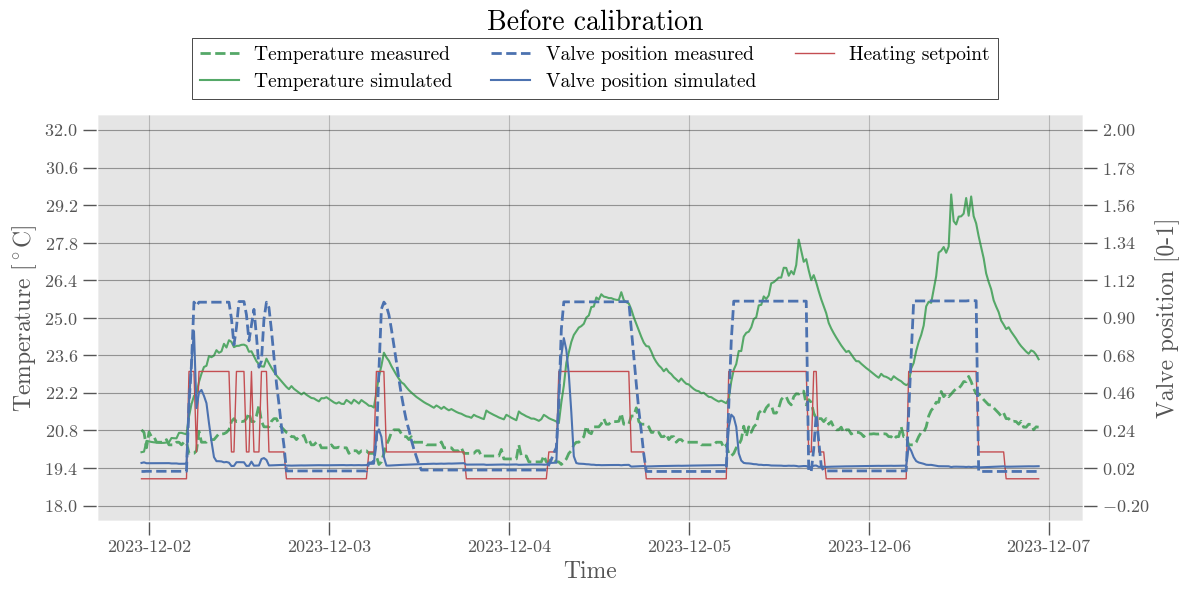

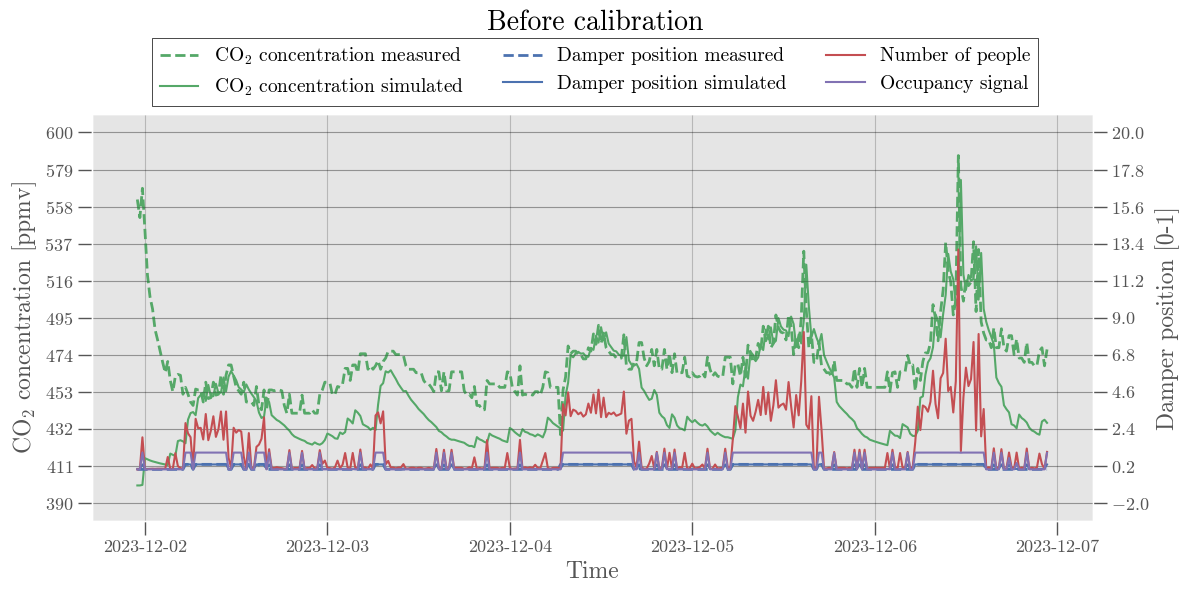

In [11]:
fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [
        tb.plot.Entry(model.components["office_temperature_sensor"].time_series_input.values,
                      label="Temperature measured", color=tb.plot.Colors.green, linewidth=2, fmt="--"),
        tb.plot.Entry(model.components["office_temperature_sensor"].output["measuredValue"].history(),
                      label="Temperature simulated", color=tb.plot.Colors.green, linewidth=1.5),
        tb.plot.Entry(model.components["office_valve_position_sensor"].time_series_input.values,
                      label="Valve position measured", color=tb.plot.Colors.blue, linewidth=2, fmt="--", axis=2),
        tb.plot.Entry(model.components["office_valve_position_sensor"].output["measuredValue"].history(),
                      label="Valve position simulated", color=tb.plot.Colors.blue, linewidth=1.5, axis=2),
        tb.plot.Entry(heating_controller.input["setpointValue"].history(),
                      label="Heating setpoint", color=tb.plot.Colors.red, linewidth=1),
    ],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    ylabel_2axis="Valve position [0-1]",
    title="Before calibration",
    show=False,
    nticks=11,
)

fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [
        tb.plot.Entry(model.components["office_co2_sensor"].time_series_input.values,
                      label=r"CO$_2$ concentration measured", color=tb.plot.Colors.green, linewidth=2, fmt="--"),
        tb.plot.Entry(model.components["office_co2_sensor"].output["measuredValue"].history(),
                      label=r"CO$_2$ concentration simulated", color=tb.plot.Colors.green, linewidth=1.5),
        tb.plot.Entry(model.components["office_damper_position_sensor"].time_series_input.values,
                      label=r"Damper position measured", color=tb.plot.Colors.blue, linewidth=2, fmt="--", axis=2),
        tb.plot.Entry(model.components["office_damper_position_sensor"].output["measuredValue"].history(),
                      label=r"Damper position simulated", color=tb.plot.Colors.blue, linewidth=1.5, axis=2),
        tb.plot.Entry(model.components["office"].input["numberOfPeople"].history(),
                      label=r"Number of people", color=tb.plot.Colors.red, linewidth=1.5, axis=2),
        tb.plot.Entry(model.components["office_occupancy_detector"].output["occupancySignal"].history(),
                      label=r"Occupancy signal", color=tb.plot.Colors.purple, linewidth=1.5, axis=2),
    ],
    ylabel_1axis=r"CO$_2$ concentration [ppmv]",
    ylabel_2axis="Damper position [0-1]",
    title="Before calibration",
    show=True,
    nticks=11,
)


### 2.7 Run Parameter Estimation

Calibrate the model using the SLSQP optimizer with automatic differentiation. `n_warmup=72` excludes the first 72 timesteps (one day at 20 minutes) from the objective, so errors from unknown initial states don't bias the parameters. On a typical laptop CPU, this takes around 5 minutes.

In [ ]:
estimator = tb.Estimator(simulator)

stage1 = estimator.estimate(
    start_time,
    end_time,
    step_size,
    parameters,
    measurements,
    n_warmup=20,
    method=("scipy", "SLSQP", "ad"),
    options={"maxiter": 5, "fast": True},
)

# Continue from stage 1's optimum.  estimate() leaves the model's parameters at
# the fitted values, so read each group's current value straight off the model.
# (Do NOT zip the input list with stage1["result_x"]: the estimator reorders
# parameters -- private first, then shared -- expands private component lists
# and collapses shared groups, so result_x is not aligned with `parameters`.)
from twin4build.utils.rgetattr import rgetattr

def _from_model(entry):
    comps, attr, _x0, lo, hi = entry[:5]
    comp = comps[0] if isinstance(comps, list) else comps
    v = float(rgetattr(comp, attr).get().reshape(-1)[0])
    eps = 1e-9 * (hi - lo)  # nudge off the bounds for the x0 checks
    return (comps, attr, min(max(v, lo + eps), hi - eps), lo, hi, *entry[5:])

parameters_stage2 = [_from_model(entry) for entry in parameters]

result = estimator.estimate(
    start_time,
    end_time,
    step_size,
    parameters_stage2,
    measurements,
    n_warmup=20,
    method=("casadi", "ipopt", "ad", "collocation"),
    options={"maxiter": 600},
)
result


In [ ]:
theta_mask = result["theta_mask"]
theta_slices = result["theta_slices"]
for id_, attr, param_idx in zip(result["component_id"], result["component_attr"], theta_mask):
    start, end = theta_slices[param_idx]
    x = result["result_x"][start:end]
    print(f"{id_}.{attr} = {x[0] if len(x) == 1 else x}")


### 2.8 Plot Calibrated Results

Run the simulation with calibrated parameters and compare against measurements.

In [ ]:
model.set_save_simulation_result(flag=True)
simulator.simulate(
    step_size=step_size,
    start_time=start_time,
    end_time=end_time,
)
print("Calibration complete.")


In [ ]:
print(len(simulator.date_time_steps[0]))
print(model.components["office_temperature_sensor"].time_series_input.values[:, :, 0].shape)
print(model.components["office_temperature_sensor"].output["measuredValue"].history()[:, :, 0].shape)


In [ ]:
fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [
        tb.plot.Entry(model.components["office_temperature_sensor"].time_series_input.values,
                      label="measured", color=tb.plot.Colors.green, linewidth=1, fmt="--"),
        tb.plot.Entry(model.components["office_temperature_sensor"].output["measuredValue"].history(),
                      label="simulated", color=tb.plot.Colors.green, linewidth=1),
        tb.plot.Entry(heating_controller.input["setpointValue"].history(),
                      label="indoor temperature", color=tb.plot.Colors.red, linewidth=1),
        tb.plot.Entry(model.components["office_valve_position_sensor"].time_series_input.values,
                      label="measured", color=tb.plot.Colors.purple, linewidth=1, fmt="--", axis=2),
        tb.plot.Entry(model.components["office_valve_position_sensor"].output["measuredValue"].history(),
                      label="simulated", color=tb.plot.Colors.purple, linewidth=1, axis=2),
    ],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    ylabel_2axis="Valve position [0-1]",
    title="After calibration",
    show=False,
    nticks=11,
)


In [ ]:
fig, axes = tb.plot.plot(
    simulator.date_time_steps,
    [
        tb.plot.Entry(model.components["office_co2_sensor"].time_series_input.values,
                      label=r"CO$_2$ concentration measured", color=tb.plot.Colors.green, linewidth=2, fmt="--"),
        tb.plot.Entry(model.components["office_co2_sensor"].output["measuredValue"].history(),
                      label=r"CO$_2$ concentration simulated", color=tb.plot.Colors.green, linewidth=1.5),
        tb.plot.Entry(model.components["office_damper_position_sensor"].time_series_input.values,
                      label=r"Damper position measured", color=tb.plot.Colors.blue, linewidth=2, fmt="--", axis=2),
        tb.plot.Entry(model.components["office_damper_position_sensor"].output["measuredValue"].history(),
                      label=r"Damper position simulated", color=tb.plot.Colors.blue, linewidth=1.5, axis=2),
    ],
    ylabel_1axis=r"CO$_2$ concentration [ppmv]",
    ylabel_2axis="Damper position [0-1]",
    title="After calibration",
    show=True,
    nticks=11,
)


---
# Part 3: Calibrated Model → Optimized Control (Optimizer)

Now that the model is calibrated, we use the Optimizer to find an optimal valve position schedule. Unlike `optimizer_example.ipynb` (which minimizes energy), the objective here is **electricity cost**: heater power is multiplied by a real Danish Elspot price time series in a small `ScalarProductSystem`, and the optimizer minimizes the summed cost subject to indoor comfort constraints. Because the price varies hour by hour, the optimal strategy is *load shifting* — pre-heating the room's thermal mass during cheap hours and coasting through expensive ones.

The decision variable is the valve position (0–1) at every timestep. The calibrated valve component converts position into water flow using its estimated authority and max flow, so the optimization runs on actuator commands a real BMS could execute.

### 3.1 Create Optimizable Valve Position Schedule

For optimization, we replace the PID controller's output signal to the valve with a schedule that the optimizer can modify directly. We also set up heating/cooling setpoint schedules for the comfort constraints.

In [ ]:
valve_position_schedule = tb.ScheduleSystem(
    weekDayRulesetDict={
        "ruleset_default_value": 0,
        "ruleset_start_minute": [0, 0],
        "ruleset_end_minute": [0, 0],
        "ruleset_start_hour": [8, 19],
        "ruleset_end_hour": [16, 20],
        "ruleset_value": [0.5, 0.5],
    },
    id="valve_position_schedule",
)

# Load real Elspot prices from Dec 11-13, 2024 and remap dates to Dec 1-3, 2023
elspot_raw = pd.read_csv(utils.get_path(["Elspotprices2023-2025.csv"]), sep=";", decimal=",")
elspot_raw["HourDK"] = pd.to_datetime(elspot_raw["HourDK"], dayfirst=True)

src_start = pd.Timestamp("2024-12-11")
src_end = pd.Timestamp("2024-12-14")  # exclusive
mask = (elspot_raw["HourDK"] >= src_start) & (elspot_raw["HourDK"] < src_end)
elspot_subset = elspot_raw.loc[mask, ["HourDK", "SpotPriceDKK"]].copy()

date_offset = pd.DateOffset(years=1, days=10)  # 2024-12-11 - 1y10d = 2023-12-01
elspot_subset["HourDK"] = elspot_subset["HourDK"] - date_offset
elspot_subset.columns = ["time", "value"]
elspot_subset["value"] = elspot_subset["value"] / 1000  # DKK/MWh -> DKK/kWh
elspot_subset = elspot_subset.sort_values("time").reset_index(drop=True)

elspot_clean_path = utils.get_path(["estimator_example", "electricity_price.csv"])
elspot_subset.to_csv(elspot_clean_path, index=False)
print("Using real Elspot prices from Dec 11-13, 2024 (remapped to Dec 1-3, 2023)")
print(f"Price range: {elspot_subset['value'].min():.4f} - {elspot_subset['value'].max():.4f} DKK/kWh")
print(elspot_subset.head())

price_schedule = tb.ScheduleSystem(filename=elspot_clean_path, datecolumn=0, valuecolumn=1, id="price_schedule")

# Multiplies Power (W) by price (DKK/kWh), with scale_factor converting W*s to kWh
costs_sensor = tb.ScalarProductSystem(
    scale_factor=step_size / 3600 / 1000,  # W -> kWh per timestep
    id="costs_sensor",
)

heating_setpoint = model.components["office_temperature_heating_setpoint"]

cooling_setpoint = tb.ScheduleSystem(
    weekDayRulesetDict={
        "ruleset_default_value": 0,
        "ruleset_start_minute": [0, 0, 0],
        "ruleset_end_minute": [0, 0, 0],
        "ruleset_start_hour": [0, 8, 17],
        "ruleset_end_hour": [8, 17, 24],
        "ruleset_value": [30, 25, 30],
    },
    id="CoolingSetpoint",
)


### 3.2 Rewire the Model for Optimization

Remove the PID heating controller's output signal to the valve and replace it with the optimizable valve position schedule. The valve component remains in the model and converts the optimized position into a water flow rate using its calibrated parameters (valve authority, max flow rate).

In [ ]:
model.remove_connection(heating_controller, space_heater_valve, "inputSignal", "valvePosition")
model.add_connection(valve_position_schedule, space_heater_valve, "scheduleValue", "valvePosition")
model.add_connection(space_heater, costs_sensor, "Power", "input_1")
model.add_connection(price_schedule, costs_sensor, "scheduleValue", "input_2")
model.load()

print("Model rewired for optimization.")
print(model)


### 3.3 Set Up Optimization Parameters

Define the optimization time window. We use a single period for the optimization run.

In [ ]:
opt_step_size = step_size
opt_start_time = [
    datetime.datetime(year=2023, month=12, day=1, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
]
opt_end_time = [
    datetime.datetime(year=2023, month=12, day=4, hour=0, minute=0, second=0,
                      tzinfo=tz.gettz("Europe/Copenhagen")),
]

print(f"Optimization period: {opt_start_time[0]} to {opt_end_time[0]} (3 days)")
print(f"Step size: {opt_step_size} seconds ({opt_step_size / 60} minutes)")
print("Using real Elspot prices from Dec 11-13, 2024")


### 3.4 Run Initial Simulation (Before Optimization)

Simulate with the default valve position schedule to see the baseline performance of the calibrated model.

In [ ]:
simulator_opt = tb.Simulator(model)
simulator_opt.simulate(step_size=opt_step_size, start_time=opt_start_time, end_time=opt_end_time)

fig, axes = tb.plot.plot(
    simulator_opt.date_time_steps,
    [
        tb.plot.Entry(space.output["indoorTemperature"].history(), label="Indoor temperature"),
        tb.plot.Entry(heating_setpoint.output["scheduleValue"].history(), label="Heating setpoint"),
        tb.plot.Entry(space_heater.output["Power"].history(), label="Space heater power", axis=2),
        tb.plot.Entry(space_heater_valve.output["valvePosition"].history(), label="Valve position", axis=3),
    ],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    ylabel_2axis="Heating Power [W]",
    ylabel_3axis="Valve Position [0-1]",
    title="Before optimization (Dec 1-3, 2023)",
    show=False,
)


### 3.5 Run Optimization

Optimize the valve position schedule to minimize heater power consumption subject to indoor temperature comfort constraints. The valve position ranges from 0 (fully closed) to 1 (fully open). On a typical laptop CPU, this takes around 2 minutes.

In [ ]:
variables = [(valve_position_schedule, "scheduleValue", 0, 1)]
objectives = [(costs_sensor, "output", "min")]
ineq_cons = [
    (space, "indoorTemperature", "upper", cooling_setpoint),
    (space, "indoorTemperature", "lower", heating_setpoint),
]

optimizer = tb.Optimizer(simulator_opt)
opt_options = {"maxiter": 300, "tol": 1e-15, "disp": True}

optimizer.optimize(
    start_time=opt_start_time,
    end_time=opt_end_time,
    step_size=opt_step_size,
    variables=variables,
    objectives=objectives,
    eq_cons=None,
    ineq_cons=ineq_cons,
    method="scipy",
    options=opt_options,
)


### 3.6 Plot Optimization Results

Visualize the optimized valve position schedule and its effect on indoor temperature and power consumption.

**What to look for:** overlay the valve position with the dashed electricity price curve — valve openings should cluster in the price valleys, with the indoor temperature rising above the heating setpoint during cheap hours (charging the thermal mass) and drifting back down toward it through the expensive hours. Comfort should still hold: temperature between the heating and cooling setpoint traces at all times (small violations are possible, since constraints are enforced through a penalty).

In [ ]:
model.add_component(cooling_setpoint)
model.add_component(heating_setpoint)

opt_results = {
    "date_time_steps":   simulator_opt.date_time_steps,
    "indoor_temperature": space.output["indoorTemperature"].history().detach().clone(),
    "heating_setpoint":   heating_setpoint.output["scheduleValue"].history().detach().clone(),
    "cooling_setpoint":   cooling_setpoint.output["scheduleValue"].history().detach().clone(),
    "power":              space_heater.output["Power"].history().detach().clone(),
    "valve_position":     space_heater_valve.output["valvePosition"].history().detach().clone(),
    "electricity_price":  price_schedule.output["scheduleValue"].history().detach().clone(),
    "cost_per_step":      costs_sensor.output["output"].history().detach().clone(),
    "step_size":          opt_step_size,
    "opt_start_time":     opt_start_time,
    "opt_end_time":       opt_end_time,
}

results_dir = utils.get_path(["generated_files", "models", "full_workflow_example", "optimization_results"])
os.makedirs(results_dir, exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
results_path = os.path.join(results_dir, f"{timestamp}_optimization.pickle")
with open(results_path, "wb") as f:
    pickle.dump(opt_results, f)
print(f"Optimization results saved to: {results_path}")

cost_1d = opt_results["cost_per_step"][:, 0, 0]
print(f"Total cost: {cost_1d.sum():.2f} DKK")
print(f"Peak cost/step: {cost_1d.max():.4f} DKK")
print(f"Peak power: {opt_results['power'][:, 0, 0].max():.1f} W")

fig, axes = tb.plot.plot(
    simulator_opt.date_time_steps,
    [
        tb.plot.Entry(opt_results["indoor_temperature"], label="Indoor temperature"),
        tb.plot.Entry(opt_results["heating_setpoint"], label="Heating setpoint"),
        tb.plot.Entry(opt_results["power"], label="Space heater power", axis=2),
        tb.plot.Entry(opt_results["valve_position"], label="Valve position", axis=3),
        tb.plot.Entry(opt_results["electricity_price"], label="Electricity price", fmt="--", axis=3),
    ],
    ylabel_1axis=r"Temperature [$^\circ$C]",
    ylabel_2axis="Power [W]",
    ylabel_3axis="Valve [0-1] / Price [DKK/kWh]",
    title="Optimization results",
    show=True,
)


---
## Summary

This notebook demonstrated the complete Twin4Build workflow:

1. **Translation**: A semantic model (Excel file with SAREF ontologies) was automatically translated into an executable simulation model, with site-specific data sources and control logic patched in via `fcn`
2. **Estimation**: 24 parameter groups — thermal RC network, radiator, PID gains, valve, dampers, CO2 mass balance — were calibrated against real sensor data using gradient-based optimization with automatic differentiation
3. **Optimization**: The calibrated model was used to find a cost-optimal valve position schedule against real electricity spot prices, exploiting the building's thermal mass for load shifting while satisfying comfort constraints

This end-to-end pipeline shows how Twin4Build enables:
- **Interoperability** through ontology-based semantic modeling
- **Accuracy** through data-driven parameter calibration
- **Efficiency** through model-based optimal control

**Where to go deeper:** each stage has its own notebook with fuller explanations — `translator_example.ipynb` (signature patterns and match selection), `estimator_example.ipynb` (method selection, fast single-shooting, collocation), and `optimizer_example.ipynb` (the optimal-control formulation).